In [1]:
import pandas as pd 
import torch
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np
import napari
import os

import shutil
from glob import glob

In [2]:
import sys
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

In [3]:
# img_name = '20260717T120225_pA_Activin_D4_48hr_W0027'
# channel_names = ['Sox17', 'Activin', 'FoxA2', 'Hoechst']
img_name = 'HAND1_Brachyury_mid_+'
channel_names = ['HAND1', 'BMP4', 'T', 'Hoechst']

cell_df = pd.read_parquet(f'../data/stitched/{img_name}_features.parquet')
print(cell_df.shape)
cell_df.head(3)

(108720, 22)


,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,...,circularity,aspect_ratio,HAND1_mean,BMP4_mean,T_mean,Hoechst_mean,HAND1+,BMP4+,T+,Hoechst+
cell_id,,,,,,,,,,,,,,,,,,,,,
1,3.854369,511.271845,103.0,40.384776,40.968686,0.875671,0.903509,0.673203,16.727027,8.077620,...,0.771157,2.070786,161.747573,112.106796,191.407767,304.854369,False,False,False,True
2,5.162437,687.705584,197.0,60.041631,59.604552,0.870833,0.907834,0.658863,23.557038,11.580135,...,0.696815,2.034263,225.553299,113.588832,180.010152,935.233503,False,False,False,True
4,11.396789,1491.277523,436.0,79.112698,77.685058,0.685703,0.954048,0.758261,27.930039,20.329760,...,0.907865,1.373850,201.169725,113.981651,194.694954,783.392202,False,False,False,True


In [4]:
if_cols = [c+'_mean' for c in channel_names if c != 'Hoechst']

# cell_df['Activin_mean'] = cell_df['Activin+'].astype(float)
cell_df['BMP4_mean'] = cell_df['BMP4+'].astype(float)

In [5]:
yif='T'
predict_type = f'mask_xBMP4_y{yif}'
# yif='Sox17'
# predict_type = f'mask_xActivin_y{yif}'
fig_dir = f'../results/figures/{img_name}/{predict_type}'
os.makedirs(fig_dir, exist_ok=True)

In [6]:
label_mask = np.load(f'../data/stitched/{img_name}.npy')
cell_mask = np.where(label_mask > 1, True, False)
print(label_mask.shape, cell_mask.shape)

(5958, 7943) (5958, 7943)


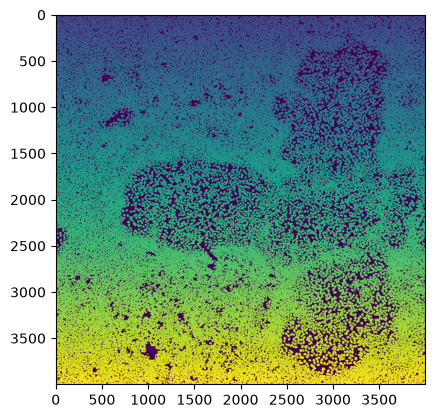

In [7]:
x_crop = [1000, 5000]
y_crop = [1000, 5000]

label_mask_ = label_mask[y_crop[0]:y_crop[1], x_crop[0]:x_crop[1]]
plt.imshow(label_mask_)

In [8]:
label_mask = label_mask_
cell_mask = cell_mask[y_crop[0]:y_crop[1], x_crop[0]:x_crop[1]]
cell_df = cell_df[cell_df.index.isin(np.unique(label_mask))]
cell_df.shape

(35049, 22)

In [9]:
GLOBAL_X_COLS = ['BMP4_mean']
NEIGHBOR_X_COLS = ['BMP4_mean']
# GLOBAL_X_COLS = ['Activin_mean']
# NEIGHBOR_X_COLS = ['Activin_mean']

SEED = 0
SCALING = 'log1p_standard'  # 'log1p_standard' | 'arcsinh' | 'robust' -- see models.gnn.ColumnScaler;
Y_COLS = [f'{yif}_mean']

### Prediction

In [10]:
from tools.morphology import split_indices, indices_to_mask, r2_table, plot_pred_vs_actual, plot_loss_curves, local_density
from models.gnn import build_prediction_data, train_neighbor_predictor, NeighborIFPredictor, predict_df as gnn_predict_df, border_mask, save_model
from models.gat import NeighborIFPredictorGAT

PRED_RADIUS = 100  # px -- create a graph (every pair within radius is connected), NOT k-NN
DENSITY_RADIUS = 50 # compute number of cells within this radius as feature
NUM_LAYERS = 4
NORMALIZE_DATA = False
HIDDEN_DIM = 128
LR = 1e-4
NUM_HEADS = 2
DISTANCE_INIT = True

N = len(cell_df)
centroids = cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)
cell_df['local_density'] = local_density(centroids, radius=DENSITY_RADIUS)  # same neighborhood as the graph itself

# A NUM_LAYERS-deep model's receptive field can chain up to NUM_LAYERS hops, each up
# to PRED_RADIUS px -- e.g. a layer-2 embedding for cell A can depend on a neighbor-
# of-a-neighbor up to 2*PRED_RADIUS away, not just a direct (1-hop) PRED_RADIUS
# neighbor. So a target cell needs its full NUM_LAYERS*PRED_RADIUS neighborhood
# imaged, or its deeper dependencies are undercounted the same way a 1-hop neighbor
# past a single PRED_RADIUS border would be.
BORDER_RADIUS = NUM_LAYERS * PRED_RADIUS
is_border = border_mask(centroids, cell_mask.shape, BORDER_RADIUS)
valid_target_idx = np.where(~is_border)[0]
print(f'{is_border.sum()} / {N} cells within {BORDER_RADIUS}px ({NUM_LAYERS} layers x {PRED_RADIUS}px) of the border -- excluded as targets')

train_pos, val_pos, test_pos = split_indices(len(valid_target_idx), val_frac=0.15, test_frac=0.15, seed=SEED)
train_idx, val_idx, test_idx = valid_target_idx[train_pos], valid_target_idx[val_pos], valid_target_idx[test_pos]
train_mask = indices_to_mask(train_idx, N)
val_mask = indices_to_mask(val_idx, N)
test_mask = indices_to_mask(test_idx, N)

pred_data = build_prediction_data(
    cell_df, if_cols, radius=PRED_RADIUS, global_x_cols=GLOBAL_X_COLS, train_idx=train_idx, scaling=SCALING,
    neighbor_x_cols=NEIGHBOR_X_COLS, 
    y_cols=Y_COLS,
    no_background_cols=['local_density', 'Activin_mean', 'BMP4_mean'],
    no_transform_cols=['local_density', 'Activin_mean', 'BMP4_mean'],
    normalize_data=NORMALIZE_DATA,
)
print('neighbor_x_cols (seen only via neighbors):', pred_data['neighbor_x_cols'])
print('global_x_cols (seen directly, incl. self):', pred_data['global_x_cols'])
print('y_cols (predicted):', pred_data['y_cols'])
print(f"{N} cells, {pred_data['edge_index'].shape[1]} directed edges (radius={PRED_RADIUS}px)")

19532 / 35049 cells within 400px (4 layers x 100px) of the border -- excluded as targets
neighbor_x_cols (seen only via neighbors): ['BMP4_mean']
global_x_cols (seen directly, incl. self): ['BMP4_mean']
y_cols (predicted): ['T_mean']
35049 cells, 2506190 directed edges (radius=100px)


In [11]:
# check if the dynamic range is good enough for prediction
data = pd.DataFrame(pred_data['y'], columns=pred_data['y_cols'])
for i, x in enumerate(pred_data['global_x_cols']):
    data[x] = pred_data['x_global'][:, i]
for i, x in enumerate(pred_data['neighbor_x_cols']):
    data[x] = pred_data['x_neighbor'][:, i]

data['centroid_x'] = cell_df['centroid_x'].values
data['centroid_y'] = cell_df['centroid_y'].values
print(data.shape)
data.tail(2)

(35049, 4)


,T_mean,BMP4_mean,centroid_x,centroid_y
35047,-0.873011,-0.182209,3765.626822,5007.128280
35048,-0.873011,-0.182209,4462.775701,5007.378505


In [12]:
# data.to_csv(f'../data/training/{img_name}_scaled.csv')

import gc
import torch

gc.collect()
torch.mps.empty_cache()

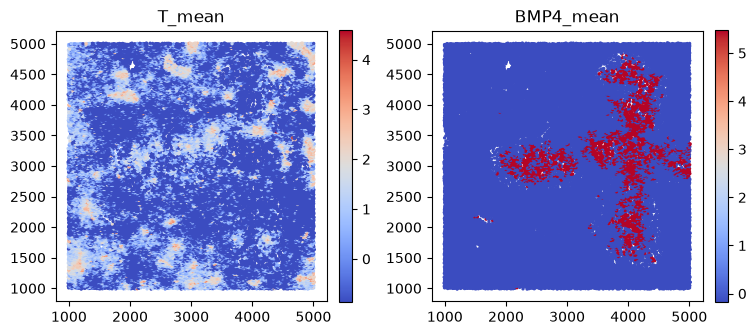

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [x for x in data.columns if 'centroid' not in x]
fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs = axs.flatten()

for i, col in enumerate(cols):
    ax = axs[i]
    sc = ax.scatter(
        data['centroid_x'], data['centroid_y'],
        c=data[col], cmap='coolwarm',
        s=2
    )
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

# Hide unused subplots
for j in range(len(cols), len(axs)):
    axs[j].set_visible(False)

fig.tight_layout()
plt.savefig(f'{fig_dir}/features.png', dpi=300)
plt.show()

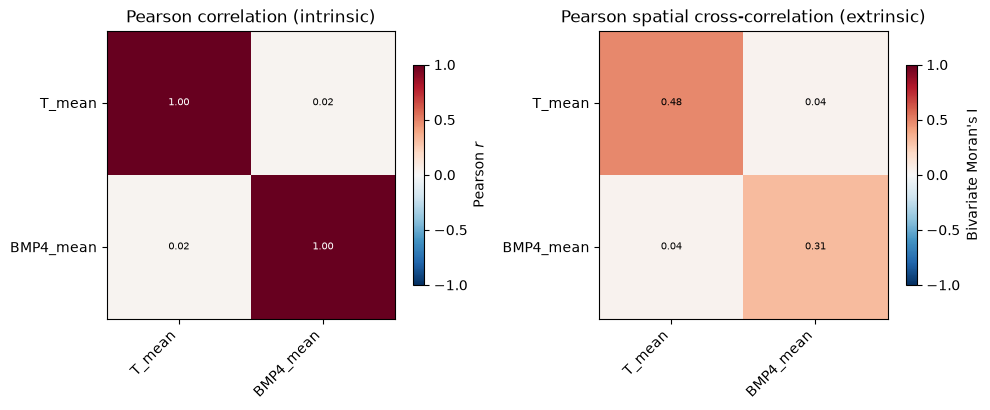

In [14]:
from tools.morphology import plot_correlation_heatmap, plot_spatial_cross_correlation

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_correlation_heatmap(data, cols, title=f'Pearson correlation (intrinsic)', corr_type='pearson', ax=axs[0])
plot_spatial_cross_correlation(data, cols, title='Pearson spatial cross-correlation (extrinsic)', corr_type='pearson', edge_index=pred_data['edge_index'], ax=axs[1])
plt.tight_layout()

In [ ]:
GNN_KWARGS = dict(
    neighbor_in_channels=len(pred_data['neighbor_x_cols']),
    global_in_channels=len(pred_data['global_x_cols']),
    num_outputs=len(pred_data['y_cols']),
    num_layers=NUM_LAYERS, 
    hidden_channels=HIDDEN_DIM,
    normalize_data=NORMALIZE_DATA
)

torch.manual_seed(SEED)
gnn_model = NeighborIFPredictor(**GNN_KWARGS)
gnn_history = train_neighbor_predictor(
    gnn_model, pred_data, train_mask, val_mask, desc='GNN', 
    epochs=500, lr=LR
)
fig_gnn_loss = plot_loss_curves({'GNN': gnn_history}, title='Neighbor -> IF prediction (radius GNN)')
plt.show()

gnn_pred_test, gnn_true_test = gnn_predict_df(gnn_model, pred_data, test_mask, cell_df.index,  y_scaler=None)
gnn_r2 = r2_table(gnn_true_test, gnn_pred_test)
display(gnn_r2)
fig_gnn_pred = plot_pred_vs_actual(gnn_true_test, gnn_pred_test, title='GNN, test set')
plt.show()

fig_gnn_loss.savefig(f'{fig_dir}/gnn_loss_curve.png', dpi=300, bbox_inches='tight')
fig_gnn_pred.savefig(f'{fig_dir}/gnn_r2.png', dpi=300, bbox_inches='tight')

save_model(
    f'../results/models/{img_name}_{predict_type}_gnn.pt', gnn_model, GNN_KWARGS, pred_data, radius=PRED_RADIUS,
    density_radius=DENSITY_RADIUS, normalize_data=NORMALIZE_DATA,
)

In [27]:
gc.collect()
torch.mps.empty_cache()

# PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0

In [ ]:
GAT_KWARGS = dict(
    neighbor_in_channels=len(pred_data['neighbor_x_cols']),
    global_in_channels=len(pred_data['global_x_cols']),
    num_outputs=len(pred_data['y_cols']),
    num_layers=NUM_LAYERS,
    hidden_channels=HIDDEN_DIM,
    heads=NUM_HEADS,
    distance_init=DISTANCE_INIT
)

torch.manual_seed(SEED)
gat_model = NeighborIFPredictorGAT(**GAT_KWARGS)
gat_history = train_neighbor_predictor(
    gat_model, pred_data, train_mask, val_mask, desc='GAT',
    epochs=500, lr=LR, patience=100, device='mps', batch_size=128
)
fig_gat_loss = plot_loss_curves({'GAT': gat_history}, title='Neighbor -> IF prediction (radius GAT)')
plt.show()

gat_pred_test, gat_true_test = gnn_predict_df(gat_model, pred_data, test_mask, cell_df.index,  y_scaler=None)
gat_r2 = r2_table(gat_true_test, gat_pred_test)
display(gat_r2)
fig_gat_pred = plot_pred_vs_actual(gat_true_test, gat_pred_test, title='GAT, test set')
plt.show()

fig_gat_loss.savefig(f'{fig_dir}/gat_loss_curve.png', dpi=300, bbox_inches='tight')
fig_gat_pred.savefig(f'{fig_dir}/gat_r2.png', dpi=300, bbox_inches='tight')

save_model(
    f'../results/models/{img_name}_{predict_type}_gat.pt', gat_model, GAT_KWARGS, pred_data, radius=PRED_RADIUS,
    density_radius=DENSITY_RADIUS, normalize_data=NORMALIZE_DATA
)

GAT:   0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
comparison = pd.concat({'GNN (fixed weights)': gnn_r2, 'GAT (learned attention)': gat_r2}, axis=1)
display(comparison)

GNN (fixed weights)           GAT (learned attention)          
                            R2       MAE                      R2       MAE
feature                                                                   
Sox17_mean            0.229757  0.728198                 0.26285  0.725716

### Understanding the GAT: attention weights

`WeightedNeighborConv` (the fixed-weight GNN) weights every neighbor by a deterministic
function of distance alone -- there's nothing to "interpret" there beyond the decay
curve itself. `GATConv` (the GAT) instead LEARNS its neighbor weighting, so inspecting
those learned attention weights directly shows what the model actually uses, rather
than assuming distance is what matters.

`GATConv` hands back the exact per-edge attention coefficient via
`return_attention_weights=True` -- softmax-normalized so each cell's incoming
attention still sums to 1, same property as the fixed GNN's `edge_weight`, just
learned instead of fixed. Two things worth checking:
- **Attention vs. distance**: if attention just tracks the same exponential decay the
  fixed GNN assumes, geometry is doing all the work and the learned attention isn't
  adding anything beyond it. If it doesn't correlate with distance, the model has
  found something in the neighbor FEATURES themselves that geometry alone can't explain.
- **Per-cell attention map**: for one example cell, which of its neighbors does the
  model actually lean on -- the physically closest ones, or ones with a similar/
  dissimilar marker profile regardless of exact distance?

In [ ]:
edge_attr = pred_data['edge_weight'].unsqueeze(-1)
# One list entry per GAT layer (models.gat.NeighborRadiusGAT.attention_by_layer) --
# with NUM_LAYERS > 1 there's no longer a single "the" attention weight per edge:
# every non-final layer has heads > 1 (concat=True), so a single conv(...,
# return_attention_weights=True) call on ONE layer comes back (E, heads), not the
# (E,) a scalar-per-edge plot needs -- attention_by_layer head-averages each layer
# down to (E,) and replays the SAME forward computation (dropout disabled) so the
# captured attention matches what a real forward pass actually used.
layer_attentions = gat_model.encoder.attention_by_layer(pred_data['x_neighbor'], pred_data['edge_index'], edge_attr)

centroids_t = torch.from_numpy(centroids)
src, dst = pred_data['edge_index']
edge_dist = torch.norm(centroids_t[src] - centroids_t[dst], dim=1)

# One ROW per layer -- only the FIRST layer's attention operates directly on these raw
# neighbor_x_cols values; deeper layers' attention operates on the embeddings that
# resulted from earlier layers, so a correlation there reflects an indirect/aggregate
# relationship with the raw marker, not a direct one.
neighbor_cols = pred_data['neighbor_x_cols']
n_panels = 1 + len(neighbor_cols)
n_layers = len(layer_attentions)
fig, axes = plt.subplots(n_layers, n_panels, figsize=(5 * n_panels, 5 * n_layers), sharey=True, squeeze=False)

for layer_idx, layer_att in enumerate(layer_attentions):
    ax = axes[layer_idx, 0]
    ax.scatter(edge_dist.numpy(), layer_att.numpy(), s=2, alpha=0.15, linewidths=0)
    corr = np.corrcoef(edge_dist.numpy(), layer_att.numpy())[0, 1]
    ax.set_xlabel('edge distance (px)')
    ax.set_ylabel(f'layer {layer_idx} attention weight')
    ax.set_title(f'layer {layer_idx}: distance (r = {corr:.3f})')

    for j, col in enumerate(neighbor_cols):
        ax = axes[layer_idx, j + 1]
        values = pred_data['x_neighbor'][src, j].numpy()
        ax.scatter(values, layer_att.numpy(), s=2, alpha=0.15, linewidths=0)
        corr = np.corrcoef(values, layer_att.numpy())[0, 1]
        ax.set_xlabel(f'{col} (neighbor, scaled)')
        ax.set_title(f'layer {layer_idx}: {col} (r = {corr:.3f})')

fig.suptitle('GAT attention vs. distance and neighbor markers, by layer', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gat_attention_corrs.png', dpi=300, bbox_inches='tight')
plt.show()

# Cells below (single-example-cell map, global-cols correlation) use the FINAL layer's
# attention -- the one that most directly determines what reaches the prediction head.
att_weights = layer_attentions[-1]

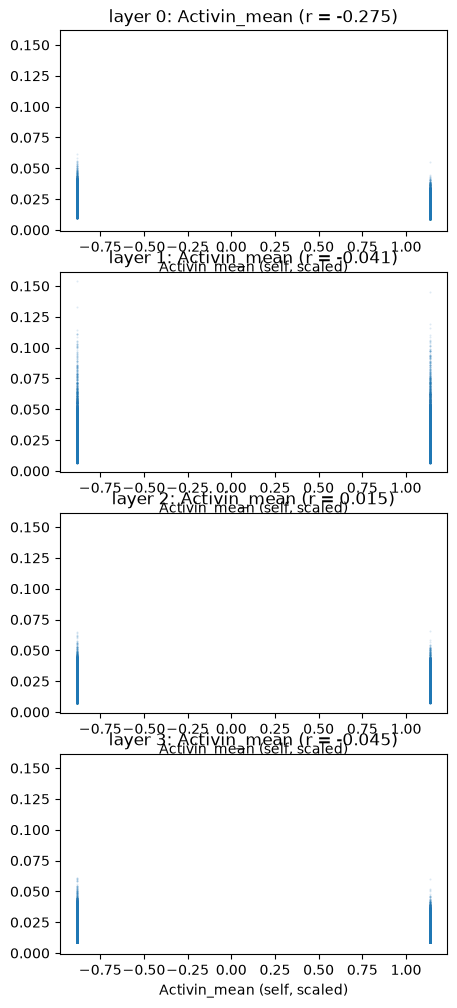

In [ ]:
global_cols = pred_data['global_x_cols']
n_panels = len(global_cols)
n_layers = len(layer_attentions)

fig, axes = plt.subplots(n_layers, n_panels, figsize=(5 * n_panels, 3 * n_layers), sharey=True, squeeze=False)

for layer_idx, layer_att in enumerate(layer_attentions):
    for j, col in enumerate(global_cols):
        ax = axes[layer_idx, j]
        values = pred_data['x_global'][src, j].numpy()
        ax.scatter(values, layer_att.numpy(), s=2, alpha=0.15, linewidths=0)
        corr = np.corrcoef(values, layer_att.numpy())[0, 1]
        ax.set_xlabel(f'{col} (self, scaled)')
        ax.set_title(f'layer {layer_idx}: {col} (r = {corr:.3f})')

fig.savefig(f'{fig_dir}/gat_attention_corrs_intrinsic.png', dpi=300, bbox_inches='tight')

In [ ]:
# One example (held-out test) cell: one attention-weight panel PER LAYER (positions are
# identical across layers -- only the coloring/attention values change, since layer 1's
# attention is a genuinely different, separately-learned quantity from layer 0's, see
# the "distance and neighbor markers, by layer" cell above), then one panel per neighbor
# marker (these don't depend on layer at all, so shown once rather than repeated).
example_cell_pos = test_idx[0]
mask_edges = (dst == example_cell_pos)
neighbor_pos = src[mask_edges].numpy()

n_layers = len(layer_attentions)
n_panels = n_layers + len(neighbor_cols)
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6))

for layer_idx, layer_att in enumerate(layer_attentions):
    neighbor_att = layer_att[mask_edges].numpy()
    ax = axes[layer_idx]
    sc = ax.scatter(centroids[neighbor_pos, 1], centroids[neighbor_pos, 0], c=neighbor_att, cmap='viridis', s=100)
    ax.scatter(centroids[example_cell_pos, 1], centroids[example_cell_pos, 0], c='red', s=350, marker='*', label='center cell')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label='attention weight', shrink=0.4)
    ax.set_title(f'layer {layer_idx}: attention weight')
    ax.legend()

for j, col in enumerate(neighbor_cols):
    ax = axes[n_layers + j]
    values = pred_data['x_neighbor'][neighbor_pos, j].numpy()
    sc = ax.scatter(centroids[neighbor_pos, 1], centroids[neighbor_pos, 0], c=values, cmap='coolwarm', s=60)
    ax.scatter(centroids[example_cell_pos, 1], centroids[example_cell_pos, 0], c='red', s=350, marker='*')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label=f'{col} (scaled)', shrink=0.4)
    ax.set_title(col)

fig.suptitle(f'GAT attention by layer vs. neighbor markers: cell {cell_df.index[example_cell_pos]}', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gat_attention_example.png', dpi=300, bbox_inches='tight')
plt.show()